# Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# DATA READING

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


# 1. Missing Values

In [3]:
df.isna().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

**Null:** No null values in the DataFrame

# 2. Column Checking

In [4]:
df.dtypes

Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

**Categorical Columns:** [Region, Model, Source_Type]

**Numerical Columns:** [Year, Month, Estimated_Deliveries,
       Production_Units, Avg_Price_USD, Battery_Capacity_kWh, Range_km,
       CO2_Saved_tons, Charging_Stations]

In [5]:
# >>> CategoricaL Columns <<<

print("Unique Values in Region: ", np.unique(df['Region']))
print("Unique Values in Model: ", np.unique(df['Model']))
print("Unique Values in Source_Type: ", np.unique(df['Source_Type']))

Unique Values in Region:  ['Asia' 'Europe' 'Middle East' 'North America']
Unique Values in Model:  ['Cybertruck' 'Model 3' 'Model S' 'Model X' 'Model Y']
Unique Values in Source_Type:  ['Estimated (Region)' 'Interpolated (Month)' 'Official (Quarter)']


# 3. EDA (Univariate)
#### We have been Taught Univariate Analysis(in video 5) so i'll perform that

### 3.1 Categorical Columns

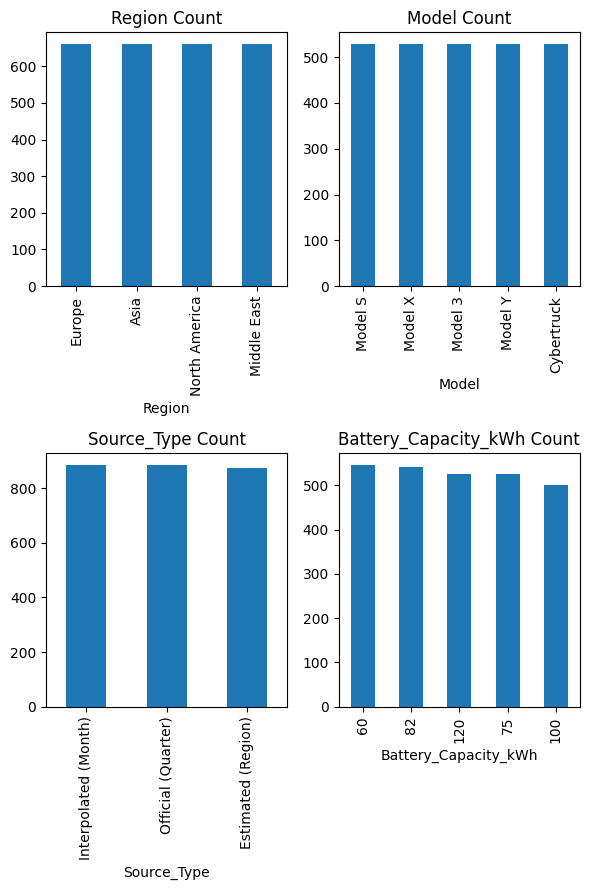

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(6,9))

df['Region'].value_counts().plot(kind='bar', ax=axes[0,0])
axes[0,0].set_title("Region Count")

df['Model'].value_counts().plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title("Model Count")

df['Source_Type'].value_counts().plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Source_Type Count")

df['Battery_Capacity_kWh'].value_counts().plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Battery_Capacity_kWh Count")

plt.tight_layout()
plt.show()

ALL the category columns have **equal categories** values other than **Battery_Capacity_kWh**

In [7]:
print(df['Region'].value_counts(),"\n")
print(df['Model'].value_counts(),"\n")
print(df['Source_Type'].value_counts(),"\n")
print(df['Battery_Capacity_kWh'].value_counts(),"\n")

# In Source_Type Estimated (Region) is just 12 less than other columns

Region
Europe           660
Asia             660
North America    660
Middle East      660
Name: count, dtype: int64 

Model
Model S       528
Model X       528
Model 3       528
Model Y       528
Cybertruck    528
Name: count, dtype: int64 

Source_Type
Interpolated (Month)    884
Official (Quarter)      884
Estimated (Region)      872
Name: count, dtype: int64 

Battery_Capacity_kWh
60     546
82     541
120    527
75     525
100    501
Name: count, dtype: int64 



### 3.2 Numeric Columns

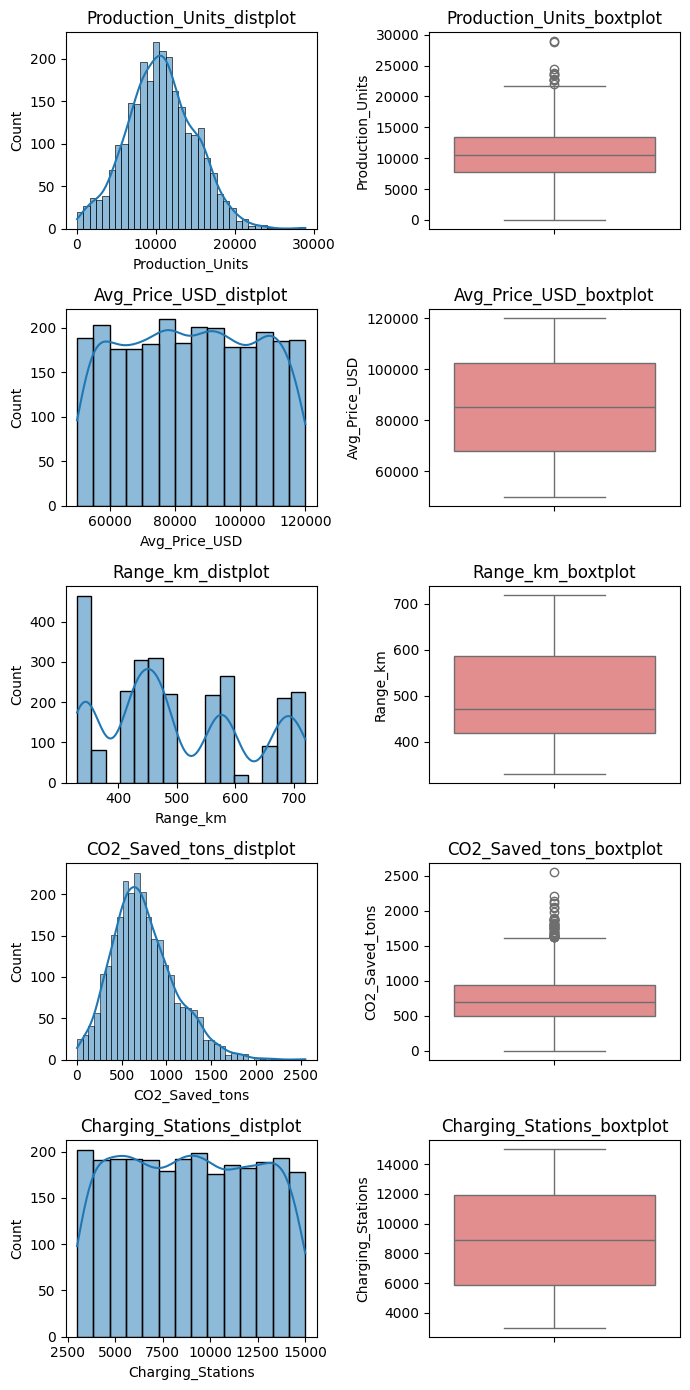

In [8]:
numeric_Col = [i for i in df.columns if i not in ['Year', 'Month', 'Battery_Capacity_kWh','Estimated_Deliveries','Region','Model','Source_Type']]

fig, axes = plt.subplots(5, 2, figsize=(7,14))
for i, col in enumerate(numeric_Col):
    sns.histplot(df, x=col, ax=axes[i,0], kde=True)
    axes[i,0].set_title(f'{col}_distplot')
    
    sns.boxplot(df, y=col, ax=axes[i,1], color='lightcoral')
    axes[i,1].set_title(f'{col}_boxtplot')

plt.tight_layout()
plt.show()


# Analysis From Dist and boxplot

**Production_Units:** This is Normal distribution slight right skew. (Outlier in boxplot)
    
**Avg_Price_USD:** This is Uniform distribution (No Outlier)

**Range_km:** In this there are multiple peaks (No Outlier)

**CO2_Saved_tons:** This is right skew (Outlier in boxplot)
    
**Charging_Stations:** This is Uniform distribution (No Outlier)

### Skew check

In [9]:
df['CO2_Saved_tons'].skew()  # between 0.5 to 1  Moderate skew

0.6597998415464956

In [10]:
df['Production_Units'].skew()   # between -0.5 to 0.5 normal skew

0.12983870635252448

# 4. Outlier and Skew Fix

### 4.1 Outlier Remove

We have seen in EDA that only CO2_Saved_tons_fix and Production_Units contain outlier lets check

In [11]:
for col in numeric_Col:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    left, right = Q1 - IQR * 1.5, Q3 + IQR * 1.5
    print("Outlier in ", col ,len(df[(df[col]<left) | (df[col]>right)]))
    df[col] = df[col].clip(lower=left, upper=right)
    
df_pipe = df.copy()

Outlier in  Production_Units 12
Outlier in  Avg_Price_USD 0
Outlier in  Range_km 0
Outlier in  CO2_Saved_tons 45
Outlier in  Charging_Stations 0


# 5. Featrue Engineering, Encoding and Scaling

### 5.1 Feature adding

In [12]:
def Add_features(df):
    df['km_battery'] = df['Range_km']/df['Battery_Capacity_kWh']
    df['co2_prod'] = df['CO2_Saved_tons']/df['Production_Units']
    df['price_battery'] = df['Avg_Price_USD']/df['Battery_Capacity_kWh']
    df['price_km'] = df['Avg_Price_USD']/df['Range_km']
    return df

df = Add_features(df)
df = df.sort_values(by = ['Year', 'Month']).reset_index(drop=True)

### 5.2 One-Hot encoding
- I have observed that Battery_Encode have only 5 unique value that why i have applied encoding on it and this is a ordinal feature in this there is a order 60<75<82<100<120 so i've used **OrdinalEncoder()**

In [13]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder( categories = [[60, 75, 82, 100, 120]])
df['Battery_Encode'] = oe.fit_transform(df[['Battery_Capacity_kWh']])
df.drop(columns = ['Battery_Capacity_kWh'], inplace=True)

In [14]:
df = pd.get_dummies(df, columns=['Region', 'Model', 'Source_Type'], drop_first=True)

### 5.3 Feature Scaling

In [15]:
from sklearn.preprocessing import StandardScaler
numeric_Col_up = ['Production_Units',
       'Avg_Price_USD', 'Range_km', 'Charging_Stations', 'CO2_Saved_tons',
       'km_battery', 'co2_prod','price_battery', 'price_km']
scaler = StandardScaler()
scaled_arr = scaler.fit_transform(df[numeric_Col_up])

In [16]:
df_scaled = pd.DataFrame(scaled_arr, columns=[f'{c}_z' for c in numeric_Col_up])
for col in [i for i in df.columns if i not in numeric_Col_up]:
    df_scaled[col] = df[col]
    
X = df_scaled.drop(columns = ['Estimated_Deliveries'])
y = df['Estimated_Deliveries']

## 6. Model Traning, Cross Validation without Pipeline

### 6.1 Linear Regression with Kfold

In [17]:
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline

kf = KFold(n_splits=5, shuffle=True, random_state=42)
lr = LinearRegression()
kf_scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')
print("KF score(R2) on Linear Regression" ,kf_scores.mean().round(4))

KF score(R2) on Linear Regression 0.9943


### 6.2 Linear Regression with TimeSeriesSplit

In [18]:
from sklearn.metrics import r2_score

tscv = TimeSeriesSplit(n_splits=5)
ts_scores = []
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X), 1):
    lr = LinearRegression()
    lr.fit(X.iloc[tr_idx], y.iloc[tr_idx])
    r2 = r2_score(y.iloc[te_idx], lr.predict(X.iloc[te_idx]))
    ts_scores.append(r2)
    print(f"Fold {fold}: Train({tr_idx[0]:3d}–{tr_idx[-1]:3d})  "
          f"Test({te_idx[0]:3d}–{te_idx[-1]:3d})  R2={r2:.4f}")
    
print("\nTS Score(R2) on Linear Regression: ",np.mean(ts_scores).round(4))


Fold 1: Train(  0–439)  Test(440–879)  R2=0.9889
Fold 2: Train(  0–879)  Test(880–1319)  R2=0.9957
Fold 3: Train(  0–1319)  Test(1320–1759)  R2=0.9956
Fold 4: Train(  0–1759)  Test(1760–2199)  R2=0.9964
Fold 5: Train(  0–2199)  Test(2200–2639)  R2=0.9967

TS Score(R2) on Linear Regression:  0.9947


# 7. Pipeline
- In the current week 2 video i have learned a topic of pipelines i've applied that below so the above 6th step can be skiped 

In [19]:
df_pipe = df_pipe.sort_values(by = ['Year', 'Month']).reset_index(drop=True)
X = df_pipe.drop(columns = ['Estimated_Deliveries'])
y = df_pipe['Estimated_Deliveries']

#### 7.1 Preprocessor pipeline

In [20]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing   import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer

Num_cols = ['Production_Units', 'Avg_Price_USD', 'Range_km', 'Charging_Stations', 'CO2_Saved_tons',
 'km_battery', 'co2_prod', 'price_battery', 'price_km']

preprocessor = ColumnTransformer(transformers = [
    ('Ordinal', OrdinalEncoder( categories = [[60, 75, 82, 100, 120]]), ['Battery_Capacity_kWh']),
    ('Category', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'),
     ['Region', 'Model', 'Source_Type']),
    ('Scale', StandardScaler(), Num_cols)])

feat_transform = FunctionTransformer(Add_features, validate=False)
Linear_pipe = Pipeline([('feature', feat_transform) ,('preprocessor', preprocessor), ('model', LinearRegression())])
Ridge_pipe = Pipeline([('feature', feat_transform) ,('preprocessor', preprocessor), ('model', Ridge(alpha = 0.5))])
Lasso_pipe = Pipeline([('feature', feat_transform) ,('preprocessor', preprocessor), 
                       ('model', Lasso(alpha = 0.5, max_iter = 5000))])

#### 7.2 Cross Validation Pipeline

#### K fold

In [21]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(Linear_pipe, X, y, cv=kf, scoring='r2')
print("Linear_Score:", scores.mean().round(6))

scores = cross_val_score(Ridge_pipe, X, y, cv=kf, scoring='r2')
print("Ridge_Score:", scores.mean().round(6))

scores = cross_val_score(Lasso_pipe, X, y, cv=kf, scoring='r2')
print("Lasso_Score:", scores.mean().round(6))

Linear_Score: 0.994271
Ridge_Score: 0.994276
Lasso_Score: 0.994286


#### Time Series

In [22]:
tscv = TimeSeriesSplit(n_splits = 5)

scores = cross_val_score(Linear_pipe, X, y, cv=tscv, scoring='r2')
print("Linear_Score:", scores.mean().round(6))

scores = cross_val_score(Ridge_pipe, X, y, cv=tscv, scoring='r2')
print("Ridge_Score:", scores.mean().round(6))

scores = cross_val_score(Lasso_pipe, X, y, cv=tscv, scoring='r2')
print("Lasso_Score:", scores.mean().round(6))

Linear_Score: 0.994784
Ridge_Score: 0.994799
Lasso_Score: 0.994798


# 8. Model Evaluation on multiple Matrix

#### 8.1 Train Test Split

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


#### 8.2 All Metrics 

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error

model = {"LinearR": Linear_pipe, "Ridge  ": Ridge_pipe,
         "Lasso  ":Lasso_pipe}

for name, pipe in model.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mse = mean_squared_error(y_test, y_pred) 
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{name}    MSE: {mse.round(6)}  MAE: {mae.round(6)}  RMSE: {rmse.round(6)}  R2: {r2.round(6)}")

LinearR    MSE: 46152.33619  MAE: 156.638468  RMSE: 214.830948  R2: 0.99657
Ridge      MSE: 46725.120611  MAE: 158.061401  RMSE: 216.159942  R2: 0.996527
Lasso      MSE: 46880.096744  MAE: 158.08251  RMSE: 216.518121  R2: 0.996516


# 9. Hyperparameter Tuning

- Though there is no need of Hyperparameter Tuning as the model R2 is already best around 0.99 but as mentioned in question i've perform it on Lasso and Ridge

In [25]:
from sklearn.model_selection import GridSearchCV
    
param_grid = {'model__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 10, 50]}

ridge_search = GridSearchCV(Ridge_pipe, param_grid, cv=tscv, scoring='r2')
ridge_search.fit(X_train, y_train)
print("Best Rigid alpha: ",ridge_search.best_params_)
print("Best Rigid R2: ",ridge_search.best_score_.round(6))

lasso_search = GridSearchCV(Lasso_pipe, param_grid, cv=tscv, scoring='r2')
lasso_search.fit(X_train, y_train)
print("Best Lasso alpha: ",lasso_search.best_params_)
print("Best Lasso R2: ",lasso_search.best_score_.round(6))

Best Rigid alpha:  {'model__alpha': 0.5}
Best Rigid R2:  0.994154


C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.799e+07, tolerance: 5.663e+05
  model = cd_fast.enet_coordinate_descent(
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.386e+07, tolerance: 1.755e+06
  model = cd_fast.enet_coordinate_descent(
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation.

Best Lasso alpha:  {'model__alpha': 1.0}
Best Lasso R2:  0.994166


**In the Above matrics**
- Linear Regression MSE MAE and RMSE is minimum 
- R2 is Max

# 10. Time Series

### 10.1 ADF stationary test

In [27]:
from statsmodels.tsa.stattools import adfuller

ts_data = df_scaled.groupby(['Year', 'Month'])['Estimated_Deliveries'].sum().reset_index()
ts_data['Date'] = pd.to_datetime(ts_data[['Year', 'Month']].assign(DAY=1))
ts_data.set_index('Date', inplace=True)
deliveries = ts_data['Estimated_Deliveries']
result = adfuller(deliveries)
print("ADF Statistic: ", result[0])
print("Stationary: ",result[1] < 0.05)

ADF Statistic:  -8.880990349502865
Stationary:  True


- Target columns ADF is already Stationary no need to fix

### 10.2 ACF PACF plots

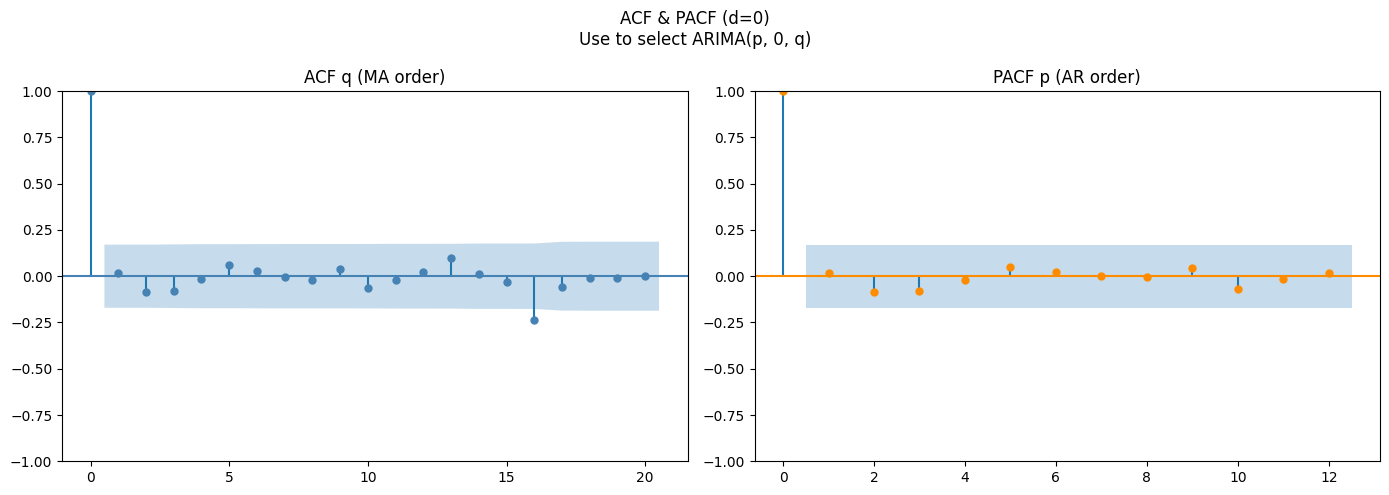

In [28]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

diff1 = ts_data['Estimated_Deliveries']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('ACF & PACF (d=0)\n'
             'Use to select ARIMA(p, 0, q)')
plot_acf (diff1, lags=min(20, len(diff1)//2), ax=axes[0], color='steelblue')
plot_pacf(diff1, lags=min(12, len(diff1)//2 - 1), ax=axes[1], method='ywm', color='darkorange')
axes[0].set_title('ACF q (MA order)')
axes[1].set_title('PACF p (AR order)')
plt.tight_layout()

### 10.3 ARIMA Model

In [29]:
train_ts = ts_data['Estimated_Deliveries'].iloc[:-6]
test_ts  = ts_data['Estimated_Deliveries'].iloc[-6:]

best_aic, best_order = np.inf, None
aic_rows = []
for p in range(0, 4):
    for d in [0,1]:
        for q in range(0, 4):
            try:
                model = ARIMA(train_ts, order=(p,d,q))
                result = model.fit()

                aic_rows.append({
                    'p': p,
                    'd': d,
                    'q': q,
                    'AIC': round(result.aic, 2),
                    'BIC': round(result.bic, 2)
                })

                if result.aic < best_aic:
                    best_aic = result.aic
                    best_order = (p, d, q)
            except:
                continue

aic_df = pd.DataFrame(aic_rows).sort_values('AIC').head(8)
print("Top ARIMA orders by AIC:")
print(aic_df.to_string(index=False))
print(f"Best: ARIMA{best_order}  AIC={best_aic:.2f}")

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information 

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No fre

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum 

Top ARIMA orders by AIC:
 p  d  q     AIC     BIC
 1  0  1 2817.41 2828.76
 2  0  2 2817.99 2835.01
 1  0  0 2818.57 2827.08
 0  0  1 2818.63 2827.14
 2  0  1 2819.13 2833.31
 2  0  3 2819.81 2839.67
 3  0  2 2819.85 2839.71
 0  0  2 2819.89 2831.23
Best: ARIMA(1, 0, 1)  AIC=2817.41


C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### Best model Fit with best parameter (1,0,1)

In [30]:
final_model = ARIMA(train_ts, order=best_order).fit()
print(final_model.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  126
Model:                   ARIMA(1, 0, 1)   Log Likelihood               -1404.706
Date:                  Mon, 01 Jun 2026   AIC                           2817.411
Time:                          00:04:52   BIC                           2828.756
Sample:                      01-01-2015   HQIC                          2822.020
                           - 06-01-2025                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.984e+05    486.818    407.570      0.000    1.97e+05    1.99e+05
ar.L1          0.9302      0.041     22.752      0.000       0.850       1.010
ma.L1         -0.9984      0.141    

C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\kevin\anaconda3\envs\MorX9\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### 10.4 Forcast and Ploting Result

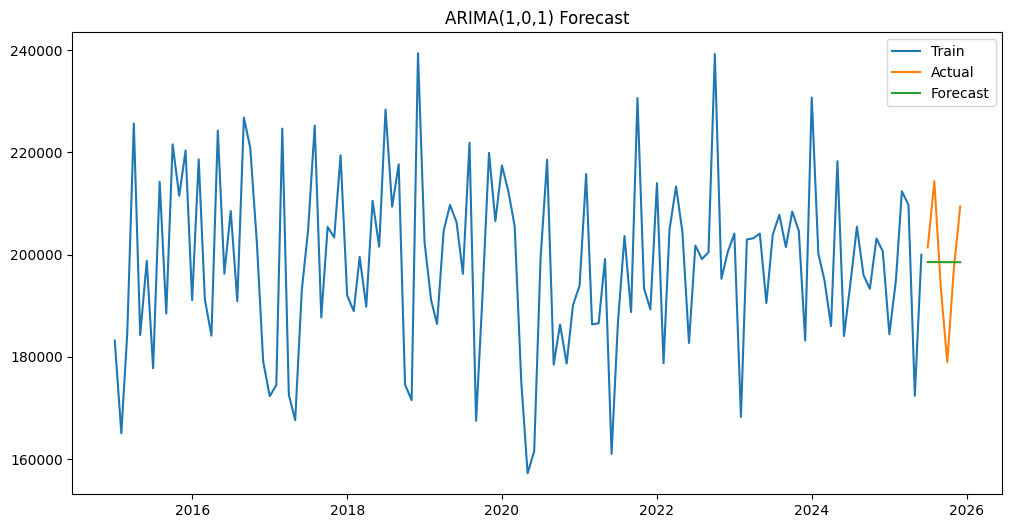

In [31]:
forecast = final_model.forecast(steps=len(test_ts))

plt.figure(figsize=(12,6))
plt.plot(train_ts.index, train_ts, label='Train')
plt.plot(test_ts.index, test_ts, label='Actual')
plt.plot(test_ts.index, forecast, label='Forecast')

plt.title('ARIMA(1,0,1) Forecast')
plt.legend()
plt.show()

### 10.5 ARIMA Model Evaluation 

In [35]:
print("MSE: ",mean_squared_error(test_ts, forecast))
print("R2: ",r2_score(test_ts, forecast))
print("RMSE: ", np.sqrt(mean_squared_error(test_ts, forecast)))
print("MAE: ", mean_absolute_error(test_ts, forecast))
print("MAPE:", mean_absolute_percentage_error(test_ts, forecast))

MSE:  131370902.18822306
R2:  -0.0023039272087772567
RMSE:  11461.714626888206
MAE:  9277.7075273941
MAPE: 0.04716070096826708


# CONCLUSION

**Arima's score is not as Good as Regression Model**
- Reason could be **Arima** is a univariate model and **Regression** is a multivariate as it is using multiple feature so this can be the reason that this model is working great with R2 around 0.99 

**Linear Regression Matrices (Best amoung Ridge, Linear and Lasso)**    
- **LinearR** = **MSE**: 46152.33619  **MAE**: 156.638468  **RMSE**: 214.830948  **R2**: 0.99657
- **Ridge** =  **MSE**: 46725.120611  **MAE**: 158.061401  **RMSE**: 216.159942  **R2**: 0.996527
- **Lasso** =  **MSE**: 47775.899631  **MAE**: 159.685361  **RMSE**: 218.576988  **R2**: 0.996449
- **ARIMA** =  **MSE**: 131370902.18822 **MAE**: 9277.70752 **RMSE**: 11461.71462 **R2**:-0.002303


**Linear is better Reason Must be the data is clean and there is no overfitting** 

In [26]:
# Linear Regression is best saving the pipeline

import joblib
joblib.dump(Linear_pipe, "Linear_pipe.joblib")

['pipeline.joblib']